In [97]:
%reset -f
import os
# print(os.getcwd())

In [98]:
import json
from pprint import pprint
# Alternar idioma para los títulos/ejes/etiquetas de posibles gráficas posteriores (EN/ES)
LANG = 'ES'

In [99]:
import sys
import logging

# 1. Create a custom logger
kernel_logger = logging.getLogger("MyJupyterLogger")
kernel_logger.setLevel(logging.DEBUG)

# 2. Prevent it from falling back to the default cell output
kernel_logger.propagate = False

# 3. Create a handler that points ONLY to the backend kernel stream
stream_handler = logging.StreamHandler(sys.__stderr__)
formatter = logging.Formatter('[%(levelname)s] %(asctime)s - %(message)s')
stream_handler.setFormatter(formatter)

# 4. Attach the handler to your logger
if not kernel_logger.handlers:
    kernel_logger.addHandler(stream_handler)

In [ ]:
%reset_selective -f "datos_edificio|^res_|^carga_|^designacion_|^mensaje_"
%reset_selective -f datos_edificio

def cargar_datos_edificio(filepath):
    """Carga la estructura JSON de la actividad."""
    with open(filepath, 'r', encoding='utf-8') as file:
        return json.load(file)


# Cargar el archivo de la actividad actual
# (Cambiar el nombre del JSON para probar Actividad 3 o Actividad 4)
ruta_archivo = '../data/Actividad5_input.json'
try:
    datos_edificio = cargar_datos_edificio(ruta_archivo)
    mensaje_carga = "Datos cargados correctamente desde" if LANG == 'ES' else "Data loaded successfully from"
    kernel_logger.info(f"{mensaje_carga}: {ruta_archivo}")
except FileNotFoundError:
    error_carga = "Archivo no encontrado. Verifica la ruta." if LANG == 'ES' else "File not found. Check path."
    print(error_carga)

pprint(datos_edificio)

In [101]:
config_path = '../data/config_normativa.json'
try:
    with open(config_path, 'r', encoding='utf-8') as file:
        config_normativa = json.load(file)
        mensaje_config = "Normas cargadas correctamente desde" if LANG == 'ES' else "Norms loaded successfully from"
    kernel_logger.info(f"{mensaje_config}: {config_path}")
except FileNotFoundError:
    error_config = "Archivo de configuración no encontrado. Verifica la ruta." if LANG == 'ES' else "Configuration file not found. Check path."
    print(error_config)

# pprint(config)

## Cálculo de Carga de Viviendas

In [102]:
def calcular_carga_viviendas(datos):
    plantas = datos['viviendas']['plantas_destinadas']
    tipos = datos['viviendas']['tipos']

    total_viviendas = 0
    suma_potencias_individuales = 0

    viviendas_basicas = 0
    viviendas_elevadas = 0

    for tipo in tipos:
        # Cantidad total de este tipo de vivienda en todo el edificio
        cantidad_total = tipo['cantidad_por_planta'] * plantas
        total_viviendas += cantidad_total

        # Criterios REBT para Grado de Electrificación Elevada (mínimo 9200 W)
        sup_mayor_160 = tipo.get('superficie_m2', 0) > config_normativa['viviendas']['umbrales_elevada']['superficie_m2']
        tiene_aa = tipo.get('aire_acondicionado', False)
        puntos_luz = tipo.get('puntos_alumbrado')
        muchos_puntos = puntos_luz is not None and puntos_luz > config_normativa['viviendas']['umbrales_elevada']['puntos_luz']

        if sup_mayor_160 or tiene_aa or muchos_puntos:
            potencia_unitaria = config_normativa['viviendas']['potencia_elevada_W']
            viviendas_elevadas += cantidad_total
        else:
            # Grado de Electrificación Básica (mínimo 5750 W)
            potencia_unitaria = config_normativa['viviendas']['potencia_basica_W']
            viviendas_basicas += cantidad_total

        suma_potencias_individuales += (potencia_unitaria * cantidad_total)

    # Cálculo del coeficiente de simultaneidad
    if total_viviendas <= 21:
        coeficiente = config_normativa['viviendas']['tabla_simultaneidad_ITC_BT_10'][total_viviendas]
    else:
        coeficiente = 15.3 + (total_viviendas - 21) * 0.5

    # Cálculo de la potencia media armónica
    potencia_media = suma_potencias_individuales / total_viviendas if total_viviendas > 0 else 0

    # Previsión de carga total para el bloque de viviendas
    carga_total = coeficiente * potencia_media

    return {
        "total_viviendas": total_viviendas,
        "basicas": viviendas_basicas,
        "elevadas": viviendas_elevadas,
        "coeficiente": coeficiente,
        "potencia_media_W": potencia_media,
        "carga_total_W": carga_total
    }

# Ejecutar y mostrar resultados
if 'datos_edificio' in locals():
    res_viv = calcular_carga_viviendas(datos_edificio)

    if LANG == 'ES':
        print("--- RESULTADOS VIVIENDAS ---")
        print(f"Total de viviendas: {res_viv['total_viviendas']}")
        print(f"  - Grado Básico (5750 W): {res_viv['basicas']}")
        print(f"  - Grado Elevado (9200 W): {res_viv['elevadas']}")
        print(f"Coeficiente de simultaneidad aplicado: {res_viv['coeficiente']}")
        print(f"Potencia media por vivienda: {res_viv['potencia_media_W']:.2f} W")
        print(f"PREVISIÓN DE CARGA (VIVIENDAS): {res_viv['carga_total_W']:.2f} W")
    else:
        print("--- DWELLINGS RESULTS ---")
        print(f"Total dwellings: {res_viv['total_viviendas']}")
        print(f"  - Basic Level (5750 W): {res_viv['basicas']}")
        print(f"  - Elevated Level (9200 W): {res_viv['elevadas']}")
        print(f"Applied simultaneity factor: {res_viv['coeficiente']}")
        print(f"Average power per dwelling: {res_viv['potencia_media_W']:.2f} W")
        print(f"TOTAL LOAD FORECAST (DWELLINGS): {res_viv['carga_total_W']:.2f} W")

--- RESULTADOS VIVIENDAS ---
Total de viviendas: 60
  - Grado Básico (5750 W): 10
  - Grado Elevado (9200 W): 50
Coeficiente de simultaneidad aplicado: 34.8
Potencia media por vivienda: 8625.00 W
PREVISIÓN DE CARGA (VIVIENDAS): 300150.00 W


## Cargas de locales

In [103]:
def calcular_carga_locales(datos):
    tipos_locales = datos['locales']['tipos']

    # Constantes reglamentarias (ITC-BT-10)
    POTENCIA_MINIMA_M2 = config_normativa['locales']['minimo_W_m2']     # W/m²
    print(f"POTENCIA_MINIMA_M2={POTENCIA_MINIMA_M2}")
    POTENCIA_MINIMA_LOCAL = config_normativa['locales']['minimo_absoluto_W']  # W

    carga_total_locales = 0
    detalles_locales = []

    for local in tipos_locales:
        tipo = local['tipo']
        cantidad = local['cantidad']
        superficie = local['superficie_m2']
        potencia_estimada = local.get('potencia_estimada_W') # Puede ser None

        # 1. Cálculo base por superficie
        potencia_por_superficie = superficie * POTENCIA_MINIMA_M2

        # 2. Garantizar el mínimo por local de 3450 W
        potencia_base = max(potencia_por_superficie, POTENCIA_MINIMA_LOCAL)

        # 3. Evaluar contra la potencia estimada si existe
        if potencia_estimada is not None:
            potencia_unitaria = max(potencia_base, potencia_estimada)
        else:
            potencia_unitaria = potencia_base

        # 4. Cálculo del subtotal por tipo
        potencia_subtotal = potencia_unitaria * cantidad
        carga_total_locales += potencia_subtotal

        detalles_locales.append({
            "tipo": tipo,
            "cantidad": cantidad,
            "superficie_m2": superficie,
            "potencia_unitaria_W": potencia_unitaria,
            "subtotal_W": potencia_subtotal
        })

    return {
        "carga_total_W": carga_total_locales,
        "detalles": detalles_locales
    }

# Ejecutar y mostrar resultados
if 'datos_edificio' in locals():
    res_locales = calcular_carga_locales(datos_edificio)

    if LANG == 'ES':
        print("--- RESULTADOS LOCALES COMERCIALES ---")
        for det in res_locales['detalles']:
            print(f"Tipo {det['tipo']} ({det['cantidad']} ud): {det['superficie_m2']} m² -> {det['potencia_unitaria_W']} W c/u (Subtotal: {det['subtotal_W']} W)")
        print("-" * 38)
        print(f"PREVISIÓN DE CARGA (LOCALES): {res_locales['carga_total_W']:.2f} W")
    else:
        print("--- COMMERCIAL PREMISES RESULTS ---")
        for det in res_locales['detalles']:
            print(f"Type {det['tipo']} ({det['cantidad']} units): {det['superficie_m2']} m² -> {det['potencia_unitaria_W']} W each (Subtotal: {det['subtotal_W']} W)")
        print("-" * 38)
        print(f"TOTAL LOAD FORECAST (PREMISES): {res_locales['carga_total_W']:.2f} W")

POTENCIA_MINIMA_M2=100
--- RESULTADOS LOCALES COMERCIALES ---
Tipo 1 (1 ud): 22 m² -> 3450 W c/u (Subtotal: 3450 W)
Tipo 2 (1 ud): 20 m² -> 3450 W c/u (Subtotal: 3450 W)
Tipo 4 (1 ud): 50 m² -> 9200 W c/u (Subtotal: 9200 W)
Tipo 5 (1 ud): 25 m² -> 11000 W c/u (Subtotal: 11000 W)
--------------------------------------
PREVISIÓN DE CARGA (LOCALES): 27100.00 W


## Cargas de Garajes y Vehiculos Electricos

In [104]:
def calcular_carga_garajes_ve(datos):
    # 1. Carga de Garajes (Iluminación y Ventilación)
    plantas_garaje = datos['garajes']['plantas']

    # Ratios reglamentarios (ITC-BT-10)
    W_M2_NATURAL = config_normativa['garajes']['ratios_ventilacion_W_m2']['natural']
    W_M2_FORZADA = config_normativa['garajes']['ratios_ventilacion_W_m2']['forzada']

    carga_garajes = 0
    detalles_garaje = []

    for planta in plantas_garaje:
        sup = planta['superficie_m2']
        vent = planta['ventilacion'].lower()

        # Selección del ratio según el tipo de ventilación
        ratio = W_M2_FORZADA if vent == "forzada" else W_M2_NATURAL

        potencia_planta = sup * ratio
        carga_garajes += potencia_planta

        detalles_garaje.append({
            "planta": planta['planta'],
            "superficie_m2": sup,
            "ventilacion": vent,
            "ratio_W_m2": ratio,
            "potencia_W": potencia_planta
        })

    # 2. Carga para Vehículos Eléctricos
    datos_ve = datos['vehiculos_electricos']
    plazas_totales = datos_ve['plazas_totales']
    preve_SPL = datos_ve['preve_SPL']

    # El cálculo normativo toma el porcentaje de las plazas según configuración
    plazas_calculo = plazas_totales * config_normativa['vehiculos_electricos']['porcentaje_plazas']
    potencia_base_ve = config_normativa['vehiculos_electricos']['potencia_base_W'] # W (16A a 230V)

    # Coeficiente según presencia de Sistema de Protección de la Línea (SPL)
    coef_SPL = config_normativa['vehiculos_electricos']['coeficientes_SPL']['con_SPL'] if preve_SPL else config_normativa['vehiculos_electricos']['coeficientes_SPL']['sin_SPL']    ;

    carga_ve = potencia_base_ve * plazas_calculo * coef_SPL

    return {
        "garajes": {
            "carga_total_W": carga_garajes,
            "detalles": detalles_garaje
        },
        "vehiculos_electricos": {
            "plazas_totales": plazas_totales,
            "plazas_calculo": plazas_calculo,
            "tiene_SPL": preve_SPL,
            "coef_aplicado": coef_SPL,
            "carga_total_W": carga_ve
        }
    }

# Ejecutar y mostrar resultados
if 'datos_edificio' in locals():
    res_garajes = calcular_carga_garajes_ve(datos_edificio)

    g_info = res_garajes['garajes']
    v_info = res_garajes['vehiculos_electricos']

    if LANG == 'ES':
        print("--- RESULTADOS GARAJES ---")
        for det in g_info['detalles']:
            print(f"Planta {det['planta']}: {det['superficie_m2']} m² (Ventilación {det['ventilacion']} a {det['ratio_W_m2']} W/m²) -> {det['potencia_W']} W")
        print(f"PREVISIÓN CARGA GARAJES: {g_info['carga_total_W']:.2f} W")

        print("\n--- RESULTADOS VEHÍCULOS ELÉCTRICOS (VE) ---")
        print(f"Plazas a prever (10% de {v_info['plazas_totales']}): {v_info['plazas_calculo']}")
        print(f"Sistema SPL: {'SÍ' if v_info['tiene_SPL'] else 'NO'} -> Coeficiente aplicado: {v_info['coef_aplicado']}")
        print(f"PREVISIÓN CARGA VE: {v_info['carga_total_W']:.2f} W")
    else:
        print("--- GARAGES RESULTS ---")
        for det in g_info['detalles']:
            print(f"Floor {det['planta']}: {det['superficie_m2']} m² ({det['ventilacion']} ventilation at {det['ratio_W_m2']} W/m²) -> {det['potencia_W']} W")
        print(f"TOTAL GARAGE LOAD: {g_info['carga_total_W']:.2f} W")

        print("\n--- ELECTRIC VEHICLES (EV) RESULTS ---")
        print(f"Forecasted spaces (10% of {v_info['plazas_totales']}): {v_info['plazas_calculo']}")
        print(f"SPL System: {'YES' if v_info['tiene_SPL'] else 'NO'} -> Applied coefficient: {v_info['coef_aplicado']}")
        print(f"TOTAL EV LOAD: {v_info['carga_total_W']:.2f} W")

--- RESULTADOS GARAJES ---
Planta -1: 450 m² (Ventilación forzada a 20 W/m²) -> 9000 W
Planta -2: 500 m² (Ventilación forzada a 20 W/m²) -> 10000 W
PREVISIÓN CARGA GARAJES: 19000.00 W

--- RESULTADOS VEHÍCULOS ELÉCTRICOS (VE) ---
Plazas a prever (10% de 35): 3.5
Sistema SPL: NO -> Coeficiente aplicado: 1.0
PREVISIÓN CARGA VE: 12880.00 W


## Carga de Servicios Generales

In [105]:
def calcular_carga_servicios_generales(datos):
    sg_datos = datos['servicios_generales']
    sg_config = config_normativa['servicios_generales']

    # 1. Ascensor
    # Mapeo estándar de potencias nominales (ajustable según los criterios del problema)
    potencias_ascensor = sg_config['potencias_ascensor_norma_MT_2_80_12_W']
    tipo_asc = sg_datos['ascensor_tipo']
    potencia_nom_asc = potencias_ascensor.get(tipo_asc, 4500)

    # ITC-BT-47: Coeficiente de 1.3 para aparatos de elevación y motores
    COEF_MOTORES = 1
    carga_ascensor = potencia_nom_asc * COEF_MOTORES

    # 2. Grupo de Presión
    potencia_nom_grupo = sg_datos['potencia_grupo_presion_W']
    carga_grupo = potencia_nom_grupo * COEF_MOTORES

    # 3. Alumbrado
    # Ratios estimados de W/m2 según eficiencia de la luminaria
    ratios_iluminacion = sg_config['ratios_iluminacion_catedra_W_m2']

    alc = sg_datos['alumbrado_zonas_comunes']
    ale = sg_datos['alumbrado_escalera']

    # Extraer el tipo de luminaria respetando mayúsculas/minúsculas
    tipo_zc = "LED" if alc['tipo_luminaria'].upper() == "LED" else "incandescente"
    tipo_esc = "LED" if ale['tipo_luminaria'].upper() == "LED" else "incandescente"

    zc_dict = ratios_iluminacion.get(tipo_zc, {})
    ratio_zc = zc_dict.get('zonas_comunes', zc_dict.get('general'))
    esc_dict = ratios_iluminacion.get(tipo_esc, {})
    ratio_esc = esc_dict.get('escaleras', esc_dict.get('general'))

    carga_alumbrado_zc = alc['superficie_m2'] * ratio_zc
    carga_alumbrado_esc = ale['superficie_m2'] * ratio_esc
    carga_alumbrado_total = carga_alumbrado_zc + carga_alumbrado_esc

    # Total Servicios Generales
    carga_total_sg = carga_ascensor + carga_grupo + carga_alumbrado_total

    return {
        "ascensor": {
            "tipo": tipo_asc,
            "nominal_W": potencia_nom_asc,
            "calculo_W": carga_ascensor
        },
        "grupo_presion": {
            "nominal_W": potencia_nom_grupo,
            "calculo_W": carga_grupo
        },
        "alumbrado": {
            "zc_W": carga_alumbrado_zc,
            "esc_W": carga_alumbrado_esc,
            "total_W": carga_alumbrado_total
        },
        "carga_total_W": carga_total_sg
    }


# Ejecutar y mostrar resultados
if 'datos_edificio' in locals():
    res_sg = calcular_carga_servicios_generales(datos_edificio)

    if LANG == 'ES':
        print("--- RESULTADOS SERVICIOS GENERALES ---")
        print(
            f"Ascensor ({res_sg['ascensor']['tipo']}): Nominal {res_sg['ascensor']['nominal_W']} W -> {res_sg['ascensor']['calculo_W']:.2f} W")
        print(
            f"Grupo de Presión: Nominal {res_sg['grupo_presion']['nominal_W']} W -> {res_sg['grupo_presion']['calculo_W']:.2f} W")
        print(f"Alumbrado Zonas Comunes y Escalera: {res_sg['alumbrado']['total_W']:.2f} W")
        print(f"PREVISIÓN CARGA SERVICIOS GENERALES: {res_sg['carga_total_W']:.2f} W")
    else:
        print("--- GENERAL SERVICES RESULTS ---")
        print(
            f"Elevator ({res_sg['ascensor']['tipo']}): Nominal {res_sg['ascensor']['nominal_W']} W -> {res_sg['ascensor']['calculo_W']:.2f} W")
        print(
            f"Water Pump: Nominal {res_sg['grupo_presion']['nominal_W']} W -> {res_sg['grupo_presion']['calculo_W']:.2f} W")
        print(f"Common Areas & Stairs Lighting: {res_sg['alumbrado']['total_W']:.2f} W")
        print(f"TOTAL GENERAL SERVICES LOAD: {res_sg['carga_total_W']:.2f} W")

--- RESULTADOS SERVICIOS GENERALES ---
Ascensor (ITA-4): Nominal 18500 W -> 18500.00 W
Grupo de Presión: Nominal 4500 W -> 4500.00 W
Alumbrado Zonas Comunes y Escalera: 1220.00 W
PREVISIÓN CARGA SERVICIOS GENERALES: 24220.00 W


## Previsión de Carga Total del Edificio

In [106]:
# Suma final de todos los componentes previamente calculados
if all(v in globals() for v in ['res_viv', 'res_locales', 'res_garajes', 'res_sg']):
    carga_total_edificio = (
            res_viv['carga_total_W'] +
            res_locales['carga_total_W'] +
            res_garajes['garajes']['carga_total_W'] +
            res_garajes['vehiculos_electricos']['carga_total_W'] +
            res_sg['carga_total_W']
    )

    # Comprobar obligatoriedad de Centro de Transformación (CT)
    requiere_CT = carga_total_edificio > 100000

    if LANG == 'ES':
        print("\n" + "=" * 45)
        print("PREVISIÓN DE CARGA TOTAL DEL EDIFICIO")
        print("=" * 45)
        print(f"Total: {carga_total_edificio:.2f} W")
        print(f"¿Requiere espacio para Centro de Transformación (>100 kW)?: {'SÍ' if requiere_CT else 'NO'}")
    else:
        print("\n" + "=" * 45)
        print("TOTAL BUILDING LOAD FORECAST")
        print("=" * 45)
        print(f"Total: {carga_total_edificio:.2f} W")
        print(f"Requires space for Transformer Substation (>100 kW)?: {'YES' if requiere_CT else 'NO'}")


PREVISIÓN DE CARGA TOTAL DEL EDIFICIO
Total: 383350.00 W
¿Requiere espacio para Centro de Transformación (>100 kW)?: SÍ


## Visualización de la Distribución de Cargas

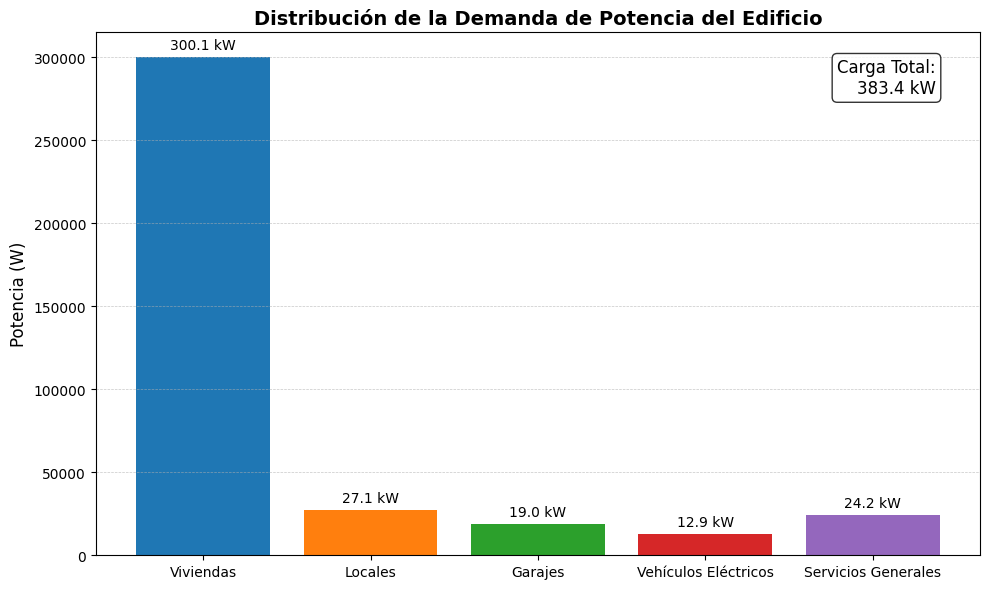

In [113]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    # 1. Force white backgrounds
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,

    # 2. Force black text and lines
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black"
})

# Tell Jupyter's specific inline backend to stop making things transparent
%config InlineBackend.print_figure_kwargs = {'facecolor' : 'white'}

# 2. Tell Jupyter's specific inline backend to stop making things transparent
%config InlineBackend.print_figure_kwargs = {'facecolor' : 'white'}

if 'carga_total_edificio' in locals():
    # Configuración de textos según idioma
    if LANG == 'ES':
        title = 'Distribución de la Demanda de Potencia del Edificio'
        labels = ['Viviendas', 'Locales', 'Garajes', 'Vehículos Eléctricos', 'Servicios Generales']
        ylabel = 'Potencia (W)'
        annotation_text = f"Carga Total:\n{carga_total_edificio / 1000:.1f} kW"
    else:
        title = 'Building Power Demand Distribution'
        labels = ['Dwellings', 'Commercial', 'Garages', 'Electric Vehicles', 'General Services']
        ylabel = 'Power (W)'
        annotation_text = f"Total Load:\n{carga_total_edificio / 1000:.1f} kW"

    # Datos
    cargas = [
        res_viv['carga_total_W'],
        res_locales['carga_total_W'],
        res_garajes['garajes']['carga_total_W'],
        res_garajes['vehiculos_electricos']['carga_total_W'],
        res_sg['carga_total_W']
    ]

    # Generación de la gráfica
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(labels, cargas, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

    # Personalización
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Anotaciones
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, yval + (max(cargas) * 0.01),
                f"{yval / 1000:.1f} kW", ha='center', va='bottom', fontsize=10)

    ax.text(0.95, 0.95, annotation_text, transform=ax.transAxes,
            fontsize=12, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

## Seleccion de la CGP

In [108]:
import math

if 'carga_total_edificio' in globals():
    # 1. Recuperar valores de la normativa
    try:
        norm_red = config_normativa['red_y_cgp']
        voltaje_tri = norm_red.get('voltaje_trifasico_V', 400)
        voltaje_mono = norm_red.get('voltaje_monofasico_V', 230)
        calibres_estandar = norm_red.get('calibres_estandar_A', [100, 160, 250, 400, 630])
        esquema_cgp = norm_red['esquemas_acometida'].get('subterranea', 9)
    except NameError:
        voltaje_tri, voltaje_mono = 400, 230
        calibres_estandar = [100, 160, 250, 400, 630]
        esquema_cgp = 9

    # 2. Determinar el tipo de suministro desde los datos del edificio
    # Asumimos trifásico por defecto en grandes demandas a menos que se indique lo contrario
    es_trifasico = True
    if 'datos_edificio' in globals() and 'edificacion_general' in datos_edificio:
        es_trifasico = datos_edificio['edificacion_general'].get('es_trifasico', True)

    # 3. Cálculo de la Intensidad
    if es_trifasico:
        intensidad_calculada = carga_total_edificio / (math.sqrt(3) * voltaje_tri)
        tipo_red_str = "Trifásica" if LANG == 'ES' else "Triphasic"
        voltaje_usado = voltaje_tri
    else:
        # Fórmula monofásica (o trifásica antigua fase-fase a 230V si tratas la P como monofásica equivalente)
        intensidad_calculada = carga_total_edificio / voltaje_mono
        tipo_red_str = "Monofásica" if LANG == 'ES' else "Monophasic"
        voltaje_usado = voltaje_mono

    # 4. Seleccionar el calibre superior más próximo
    calibre_cgp = next((c for c in calibres_estandar if c >= intensidad_calculada), None)

    if calibre_cgp:
        designacion_cgp = f"CGP-{esquema_cgp}-{calibre_cgp}A"
    else:
        designacion_cgp = "Múltiples CGP" if LANG == 'ES' else "Multiple CGPs"

    # 5. Imprimir Resultados
    if LANG == 'ES':
        print("\n" + "=" * 45)
        print("DETERMINACIÓN DE LA CGP")
        print("=" * 45)
        print(f"Potencia Máxima Total: {carga_total_edificio:.2f} W")
        print(f"Tipo de Red: {tipo_red_str} ({voltaje_usado} V)")
        print(f"Intensidad de cálculo: {intensidad_calculada:.2f} A")
        print(f"Calibre estandarizado seleccionado: {calibre_cgp} A")
        print(f"RESULTADO: {designacion_cgp}")
        if intensidad_calculada > max(calibres_estandar):
            print("AVISO: La intensidad supera el calibre máximo estándar. Se requerirán módulos adicionales.")
    else:
        print("\n" + "=" * 45)
        print("GENERAL PROTECTION BOX (CGP) DETERMINATION")
        print("=" * 45)
        print(f"Total Maximum Power: {carga_total_edificio:.2f} W")
        print(f"Network Type: {tipo_red_str} ({voltaje_usado} V)")
        print(f"Calculated Current: {intensidad_calculada:.2f} A")
        print(f"Selected Standard Rating: {calibre_cgp} A")
        print(f"RESULT: {designacion_cgp}")
        if intensidad_calculada > max(calibres_estandar):
            print("WARNING: Current exceeds maximum standard rating. Additional modules required.")
else:
    error_msg = "Error: Calcula la carga total (Celda 6) antes de determinar la CGP." if LANG == 'ES' else "Error: Calculate total load (Cell 6) before determining CGP."
    print(error_msg)


DETERMINACIÓN DE LA CGP
Potencia Máxima Total: 383350.00 W
Tipo de Red: Trifásica (400 V)
Intensidad de cálculo: 553.32 A
Calibre estandarizado seleccionado: 630 A
RESULTADO: CGP-9-630A


In [109]:
import json
import datetime

# A dictionary collecting your variables of interest
var_names = ["config_normativa", "datos_edificio","res_viv","res_locales","res_garajes","res_sg","carga_total_edificio","designacion_cgp"]

# 2. Automatically build the dictionary using locals()
# (Use globals() instead if these are defined at the top level of your script)
my_variables = {name: locals().get(name, None) for name in var_names}

# pprint(my_variables)

# Create a timestamped filename
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
json_file = f"my_variables_{timestamp}.json"

# Export to JSON
with open(json_file, "w") as file:
    # 'indent=4' is the magic argument that makes it highly readable in PyCharm
    json.dump(my_variables, file, indent=4)

kernel_logger.info(f"Variables successfully saved to: {json_file}")